<h1 style="color: steelblue;">An Analysis of Sleep: The Data Behind Disorders</h1>
<span style="color: steelblue; font-size: 14px;">
<b>This notebook analyzes the Sleep Health and Lifestyle dataset to answer two questions:<br>
1. What lifestyle and health factors best predict a sleep disorder?<br>
2. What lifestyle and health factors translate to better sleep quality?</b>
</span>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             r2_score, RocCurveDisplay)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import make_pipeline

<h2 style="color: steelblue;">1. Data Loading & Cleaning</h2>
<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Dataset:</b></span> Sleep Health and Lifestyle Dataset 
by Laksika Tharmalingam. 374 observations across 12 features including sleep duration, 
quality, stress level, BMI, blood pressure, and sleep disorder status.
</div>

In [4]:
sleep_df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv", index_col=0)
sleep_df.reset_index(inplace=True, drop=True)

print(f"Dataset shape: {sleep_df.shape}")
print(f"\nMissing values:\n{sleep_df.isna().sum()}")
sleep_df.head()

Dataset shape: (374, 12)

Missing values:
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


<h3 style="color: steelblue;">Feature Engineering</h3>
<span style="color: steelblue; font-size: 14px;">
<b>
I applied three encoding strategies:

1) One-hot encoding (turns a categorical column into separate 0/1 columns): Gender, Occupation, BMI Category, and Sleep Disorder.

2) Custom encoding for Blood Pressure: the raw values arrive as a single string like 120/80, which a model can't read as a number. I split it into separate Systolic and Diastolic columns, then bin those into clinical levels (Low / Normal / Elevated / High).

3) I also create a Disorder Present (True/False) column to use as the prediction target for Question 1.

Note on scaling: the numeric features (age, heart rate, etc.) sit on very different ranges, so the linear and logistic models need them rescaled to a common 0–1 range otherwise a model can over-weight a feature just because its numbers are larger. I deliberately do not scale here. The scaling is done inside each model's Pipeline, so the scaler is fit on the training data only. If I fit it on the full dataset at this stage, it would let information from the test set (its min and max) leak into training and inflate the results.</b>
</span>

In [6]:
# Sleep Disorder: treat missing as "Healthy" (= no disorder)
sleep_df['Sleep Disorder'] = sleep_df['Sleep Disorder'].fillna('Healthy')

sleep_df['Disorder Present'] = sleep_df['Sleep Disorder'].apply(
    lambda x: x in ('Sleep Apnea', 'Insomnia'))

one_hot_dis = pd.get_dummies(sleep_df['Sleep Disorder'], prefix='DIS')
sleep_df = pd.concat([sleep_df, one_hot_dis], axis=1)

# Blood Pressure encoding 
sleep_df[['Systolic', 'Diastolic']] = (
    sleep_df['Blood Pressure'].str.split('/', expand=True).astype(int))

def categorize_bp(row):
    if row['Systolic'] < 90 and row['Diastolic'] < 60:
        return 'Low'
    elif row['Systolic'] < 120 and row['Diastolic'] < 80:
        return 'Normal'
    elif row['Systolic'] >= 140 or row['Diastolic'] >= 90:
        return 'High'
    else:
        return 'Elevated'

sleep_df['BP_Category'] = sleep_df.apply(categorize_bp, axis=1)
bp_dummies = pd.get_dummies(sleep_df['BP_Category'], prefix='BP')
sleep_df = pd.concat([sleep_df, bp_dummies], axis=1)

# Occupation / Gender / BMI one-hot encoding 
occ_dummies = pd.get_dummies(sleep_df['Occupation'])
sleep_df = pd.concat([sleep_df, occ_dummies], axis=1)

gen_dummies = pd.get_dummies(sleep_df['Gender'])
sleep_df = pd.concat([sleep_df, gen_dummies], axis=1)

sleep_df['BMI Category'] = sleep_df['BMI Category'].replace(
    {'Normal Weight': 'Normal'})
bmi_dummies = pd.get_dummies(sleep_df['BMI Category'])
sleep_df = pd.concat([sleep_df, bmi_dummies], axis=1)

# numeric columns are intentionally left unscaled
scale_cols = ['Age', 'Sleep Duration', 'Heart Rate',
              'Physical Activity Level', 'Daily Steps']

print("Feature engineering complete")
print(f"New shape: {sleep_df.shape}")
sleep_df.head(3)

Feature engineering complete
New shape: (374, 38)


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,...,Sales Representative,Salesperson,Scientist,Software Engineer,Teacher,Female,Male,Normal,Obese,Overweight
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,...,False,False,False,True,False,False,True,False,False,True
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,...,False,False,False,False,False,False,True,True,False,False
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,...,False,False,False,False,False,False,True,True,False,False


<h2 style="color: steelblue;">2. Exploratory Data Analysis</h2>
<span style="color: steelblue; font-size: 14px;">
<b>Before modeling it is very important to visualize the distributions of the key variables and their 
relationships to sleep disorder status and sleep quality.</b>
</span>

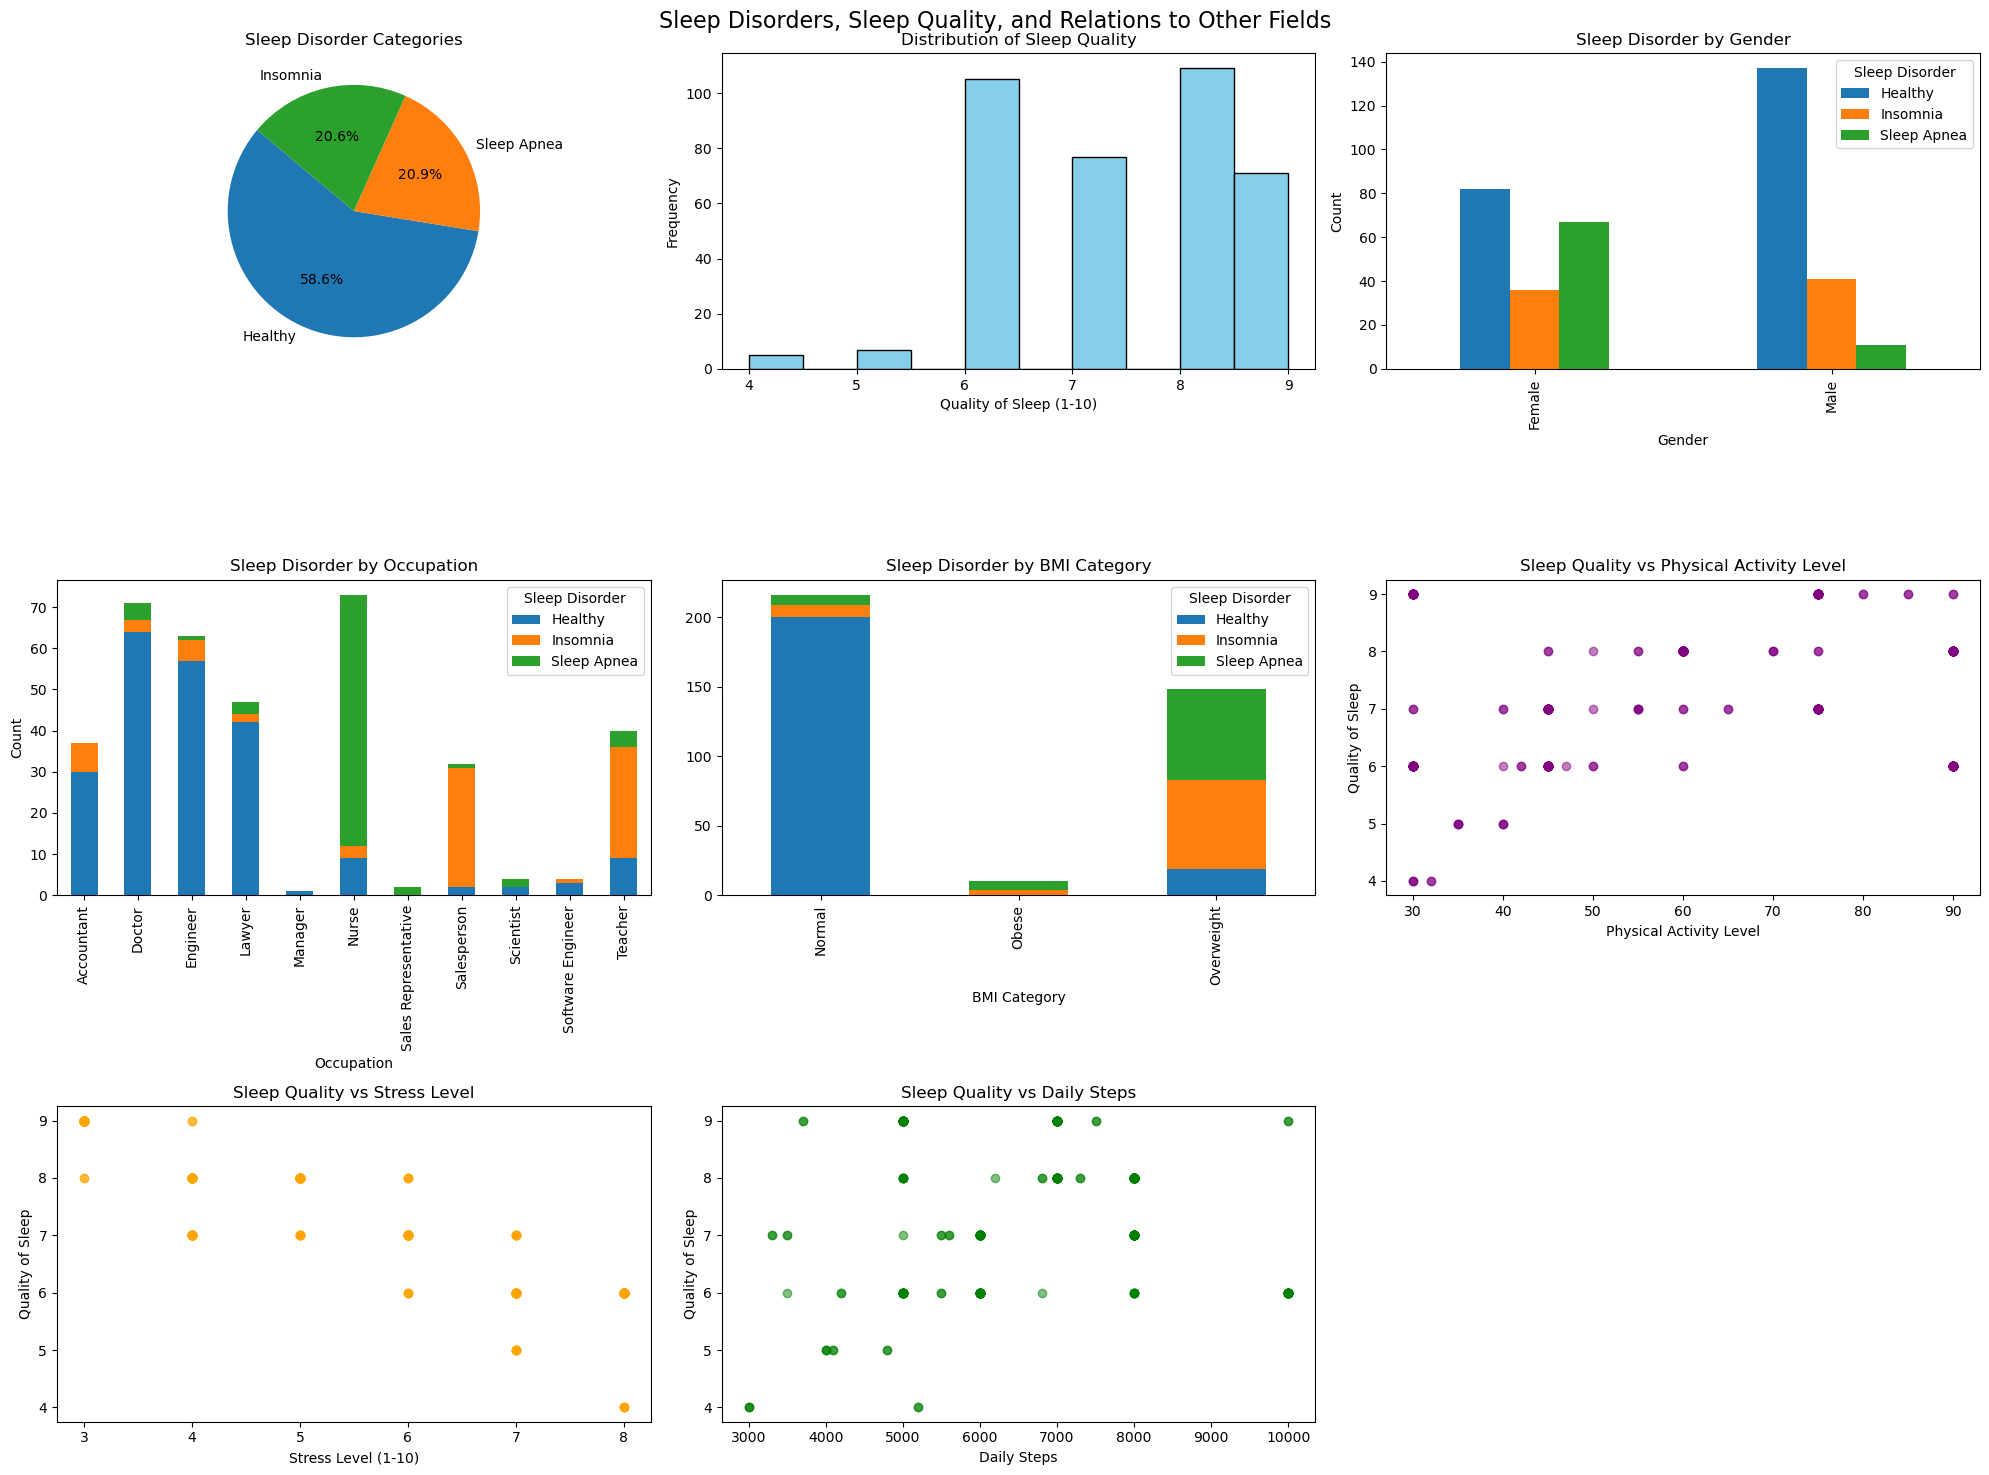

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle("Sleep Disorders, Sleep Quality, and Relations to Other Fields",
             fontsize=16)

# Pie chart: Sleep Disorder percentages
disorder_counts = sleep_df['Sleep Disorder'].value_counts(dropna=False)
axes[0, 0].pie(disorder_counts, labels=disorder_counts.index,
               autopct='%1.1f%%', startangle=140)
axes[0, 0].set_title('Sleep Disorder Categories')

# Histogram: Distribution of Sleep Quality
axes[0, 1].hist(sleep_df['Quality of Sleep'], bins=10,
                color='skyblue', edgecolor='black')
axes[0, 1].set_title('Distribution of Sleep Quality')
axes[0, 1].set_xlabel('Quality of Sleep (1-10)')
axes[0, 1].set_ylabel('Frequency')

# Bar chart: Sleep Disorder by Gender
gender_disorder = sleep_df.groupby(
    ['Gender', 'Sleep Disorder']).size().unstack(fill_value=0)
gender_disorder.plot(kind='bar', ax=axes[0, 2])
axes[0, 2].set_title('Sleep Disorder by Gender')
axes[0, 2].set_xlabel('Gender')
axes[0, 2].set_ylabel('Count')

# Bar chart: Sleep Disorder by Occupation
occ_disorder = sleep_df.groupby(
    ['Occupation', 'Sleep Disorder']).size().unstack(fill_value=0)
occ_disorder.plot(kind='bar', stacked=True, ax=axes[1, 0])
axes[1, 0].set_title('Sleep Disorder by Occupation')
axes[1, 0].set_xlabel('Occupation')
axes[1, 0].set_ylabel('Count')

# Bar chart: Sleep Disorder by BMI
bmi_cols = ['Normal', 'Obese', 'Overweight']
bmi_disorder = sleep_df[bmi_cols + ['Sleep Disorder']].copy()
bmi_disorder = bmi_disorder.melt(id_vars='Sleep Disorder', value_vars=bmi_cols)
bmi_disorder = bmi_disorder[bmi_disorder['value'] == 1]
bmi_counts = bmi_disorder.groupby(
    ['variable', 'Sleep Disorder']).size().unstack(fill_value=0)
bmi_counts.plot(kind='bar', stacked=True, ax=axes[1, 1])
axes[1, 1].set_title('Sleep Disorder by BMI Category')
axes[1, 1].set_xlabel('BMI Category')

# Scatter: Sleep Quality vs Physical Activity
axes[1, 2].scatter(sleep_df['Physical Activity Level'],
                   sleep_df['Quality of Sleep'], alpha=0.5, color='purple')
axes[1, 2].set_title('Sleep Quality vs Physical Activity Level')
axes[1, 2].set_xlabel('Physical Activity Level')
axes[1, 2].set_ylabel('Quality of Sleep')

# Scatter: Sleep Quality vs Stress Level
axes[2, 0].scatter(sleep_df['Stress Level'],
                   sleep_df['Quality of Sleep'], alpha=0.5, color='orange')
axes[2, 0].set_title('Sleep Quality vs Stress Level')
axes[2, 0].set_xlabel('Stress Level (1-10)')
axes[2, 0].set_ylabel('Quality of Sleep')

# Scatter: Sleep Quality vs Daily Steps
axes[2, 1].scatter(sleep_df['Daily Steps'],
                   sleep_df['Quality of Sleep'], alpha=0.5, color='green')
axes[2, 1].set_title('Sleep Quality vs Daily Steps')
axes[2, 1].set_xlabel('Daily Steps')
axes[2, 1].set_ylabel('Quality of Sleep')

axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Key EDA Findings:</b></span><br><br>
<b>Class Distribution (Pie Chart):</b> 58.6% of observations are healthy with Sleep Apnea (20.9%) 
and Insomnia (20.6%) roughly equal. Noting that about 40% have disorders which is relevant context to be aware about when making interpretation.
    <br><br>
<b>Sleep Quality (Histogram):</b> Scores cluster between 6-9 with very few observations below 6. This suggests that the dataset could be more skewed towards higher sleep quality which could affect model performance on predicting very poor sleep quality<br><br>

<b>Sleep Disorder by Gender:</b> Females show proportionally higher rates of both Sleep Apnea and 
Insomnia compared to males. This motivates adding gender as a feature in our models.<br><br>
<b>Occupation:</b> Nurses and salespeople show higher disorder rates while 
engineers and accountants tend to be healthier. This suggests that occupation-related stress 
and schedules play a role.<br><br>
<b>BMI:</b> Overweight individuals show dramatically higher Sleep Apnea rates. This is a consistent statistic with modern day medical observations (excess weight leads to obstructed airways during sleep).
<br><br>
<b>Stress & Physical Activity:</b> Higher stress is visually associated with lower 
sleep quality. Physical activity shows a weaker visual pattern.
</div>

<h2 style="color: steelblue;">3. Question 1: What factors predict a sleep disorder?</h2>
<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Approach:</b></span> 


I first fit a LASSO logistic regression and use permutation importance to rank the encoded features and identify the most predictive variables. Then, I examine the most clinically relevant continuous health markers (blood pressure, heart rate, sleep quality, age) one at a time with single variable logistic regression, to see how strong each is on its own.
<br><br>
LASSO is logistic regression with an L1 penalty that shrinks unimportant coefficients to exactly zero. Permutation importance checks to see how much accuracy drops if you randomly shuffle the variable so it carries no information; a large drop means the model relied on that feature
</div>

LASSO Training Accuracy: 0.910
LASSO Test Accuracy:     0.895


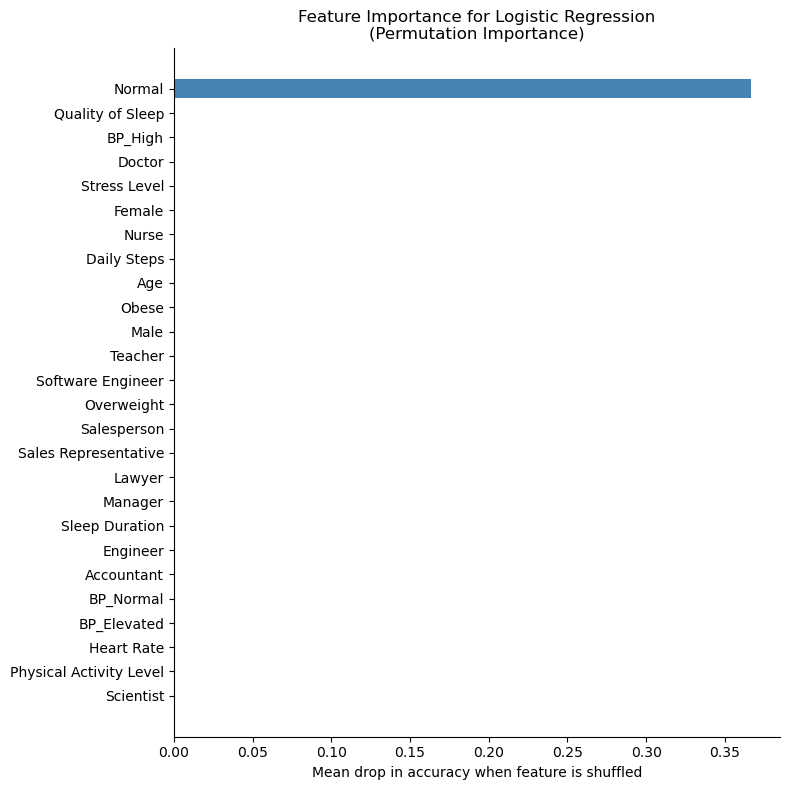

In [11]:
features = ['Normal', 'BP_High', 'Doctor', 'Stress Level', 'Female', 'Nurse',
            'Daily Steps', 'Age', 'Obese', 'Male', 'Teacher', 'Software Engineer',
            'Scientist', 'Salesperson', 'Sales Representative', 'Lawyer', 'Manager',
            'Sleep Duration', 'Engineer', 'Accountant', 'BP_Normal', 'BP_Elevated',
            'Heart Rate', 'Physical Activity Level', 'Quality of Sleep', 'Overweight']

X = sleep_df[features]
y = sleep_df['Disorder Present']

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=0, stratify=y_tmp)

# LASSO logistic regression for feature selection.
# Scaler lives INSIDE the pipeline -> fit on X_train only, no leakage.
lasso_model = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(penalty='l1', solver='liblinear',
                       C=0.25, max_iter=2000, random_state=0))
lasso_model.fit(X_train, y_train)
print(f"LASSO Training Accuracy: {lasso_model.score(X_train, y_train):.3f}")
print(f"LASSO Test Accuracy:     {lasso_model.score(X_test,  y_test):.3f}")

# Permutation importance = mean drop in ACCURACY when a feature is shuffled
perm = permutation_importance(lasso_model, X_valid, y_valid,
                              n_repeats=1000, random_state=0,
                              scoring='accuracy')
imp_df = (pd.DataFrame({'feature': features,
                        'importance': perm.importances_mean})
            .sort_values('importance', ascending=True))

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
ax.set_title('Feature Importance for Logistic Regression\n(Permutation Importance)')
ax.set_xlabel('Mean drop in accuracy when feature is shuffled')   # <- fixed
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>LASSO Results:</b></span> Training accuracy 91.0% 
and test accuracy 89.5% are very close. This confirms the model generalizes well 
without overfitting.<br><br>
<span style="color: steelblue;"><b>Feature Importance:</b></span> Results show that Normal BMI is 
overwhelmingly the most important predictor; Shuffling it causes the largest drop in accuracy of any variable. This suggests that BMI category is the dominant 
signal in predicting sleep disorder presence and this is consistent with the EDA finding that 
overweight individuals have dramatically higher disorder rates. Most other features show near-zero permutation importance, but that is partly a result of using LASSO: the L1 penalty drove many of their coefficients to exactly zero, so shuffling a feature the model already ignores cannot change its predictions. Near-zero importance here therefore reflects both genuine redundancy and the fact that LASSO had already dropped those features.

</div>

<h3 style="color: steelblue;">Individual Logistic Regressions — Top Predictors</h3>
<span style="color: steelblue; font-size: 14px;">
<b>Here I run a separate logistic regression for each of the top 5 clinically meaningful health markers identified by feature selection, predicting whether a sleep disorder is present based on 
that single variable.These are continuous markers chosen for individual analysis, not the exact ranking from the permutation plot above, which ranked the one-hot encoded features. The S-shaped logistic curve shows how the probability of having a disorder changes as the variable increases.</b>
</span>

Diastolic            Test Accuracy: 0.893


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


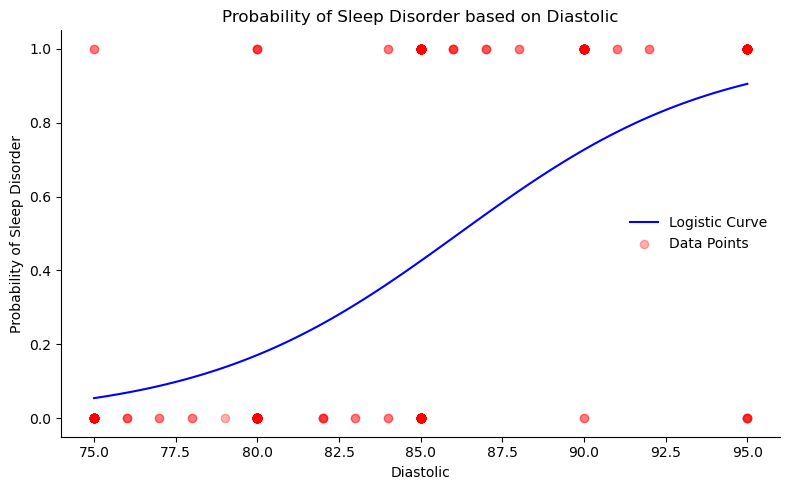

Systolic             Test Accuracy: 0.907


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


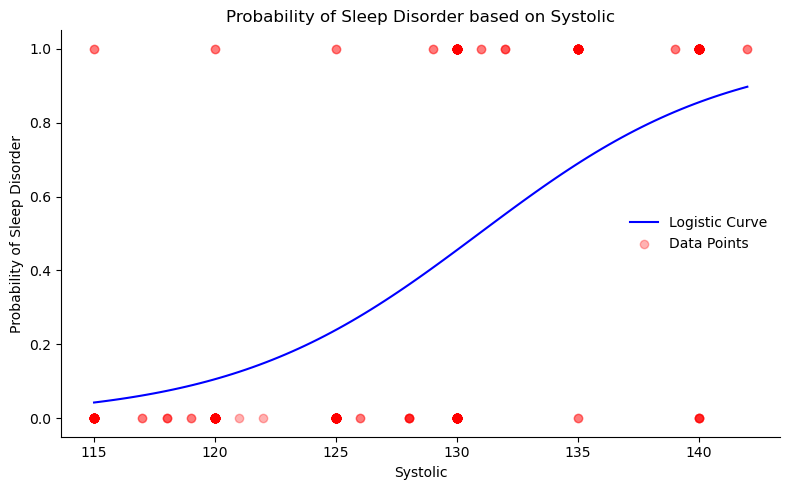

Heart Rate           Test Accuracy: 0.680


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


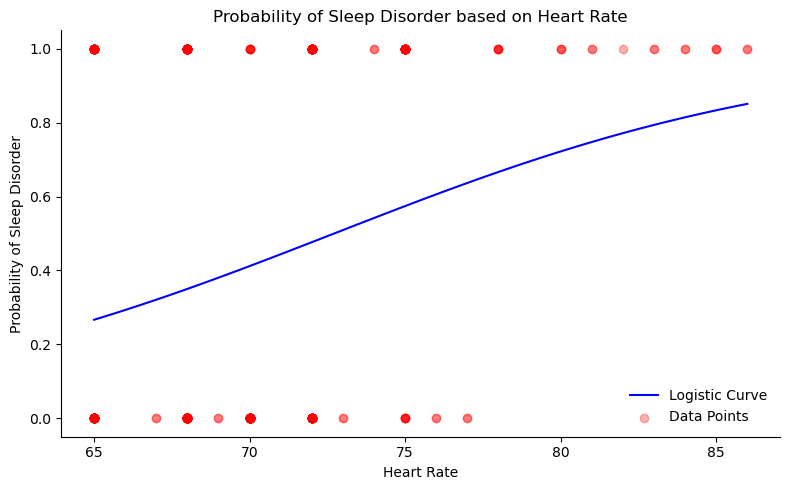

Quality of Sleep     Test Accuracy: 0.640


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


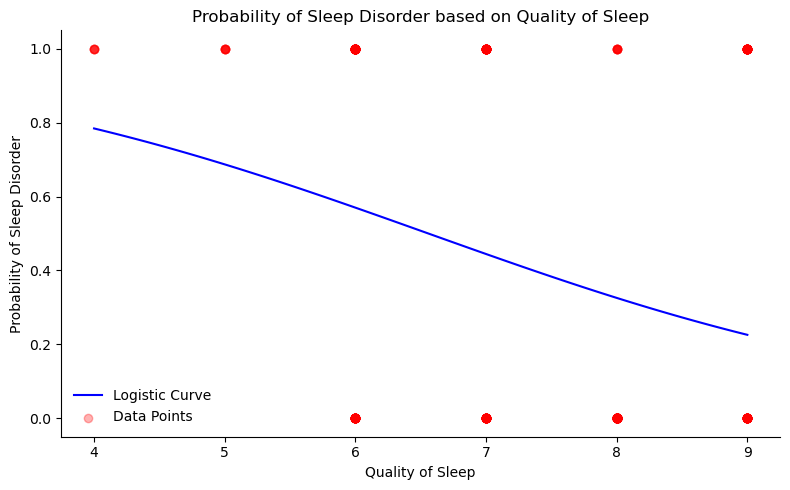

Age                  Test Accuracy: 0.693


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


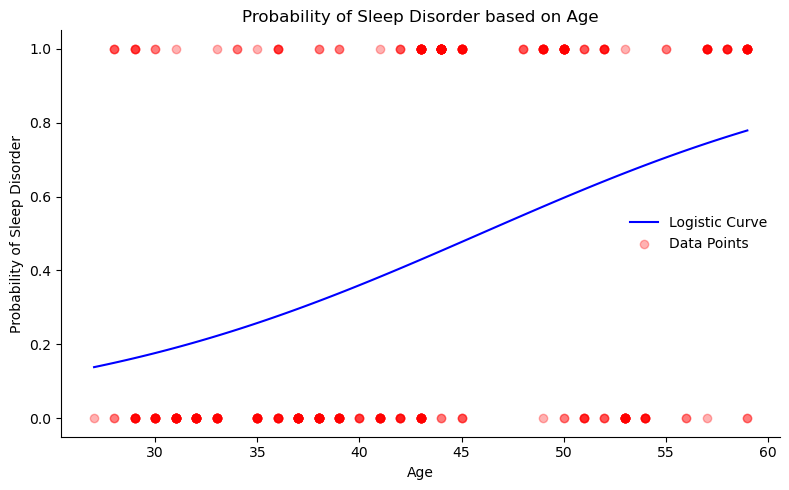

In [14]:
top_predictors = ['Diastolic', 'Systolic', 'Heart Rate',
                  'Quality of Sleep', 'Age']

for var in top_predictors:
    X = sleep_df[[var]]
    y = sleep_df['Disorder Present']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    model = make_pipeline(
        MinMaxScaler(),
        LogisticRegression(random_state=42, max_iter=1000))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{var:20} Test Accuracy: {acc:.3f}")

    x_range = np.linspace(X[var].min(), X[var].max(), 100).reshape(-1, 1)
    y_proba = model.predict_proba(x_range)[:, 1]

    plt.figure(figsize=(8, 5))
    plt.plot(x_range, y_proba, color='blue', label='Logistic Curve')
    plt.scatter(X, y, color='red', alpha=0.3, label='Data Points')
    plt.xlabel(var)
    plt.ylabel('Probability of Sleep Disorder')
    plt.title(f'Probability of Sleep Disorder based on {var}')
    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [15]:
pd.crosstab(sleep_df['BP_Category'], sleep_df['Disorder Present'])

Disorder Present,False,True
BP_Category,,
Elevated,173,60
High,7,93
Normal,39,2


<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Individual Logistic Regression Findings:</b></span><br><br>

<b>Blood Pressure (Systolic 0.91, Diastolic 0.89 test accuracy):</b> Blood pressure is the strongest single predictor by a wide margin. It is near-deterministic at the extremes, among people with Normal blood pressure 95% are healthy (39/41), and among those with High blood pressure 93% have a disorder (93/100), but the largest group, Elevated (62% of the sample), is genuinely mixed (74% healthy, 26% disorder). The continuous blood-pressure value adds resolution within that ambiguous middle, which is why the continuous predictor (0.91) clearly beats a simple category split (about 0.82). The high accuracy still reflects how tightly blood pressure tracks the disorder label in this dataset, as much as any model sophistication.

<b>Heart Rate (0.68):</b> The curve is rising gradually which conveys that higher heart rate increases disorder risk <br><br>

<b>Quality of Sleep (0.64):</b> The Quality of Sleep curve goes down signaling that better sleep quality means lower disorder probability<br><br>
<b>Age Curve (0.69):</b> Age curve rises; Older people are more likely to have a disorder
</div>

<h3 style="color: steelblue;">Extended Analysis: Random Forest Classifier</h3>
<span style="color: steelblue; font-size: 14px;">
<b>We extend our analysis using a Random Forest; An ensemble of 100 decision trees 
that reduces overfitting through bagging. Bagging minimizes variance errors and makes the model more reliable. This gives both better predictive accuracy 
and a clearer picture of which features matter most across all variables simultaneously.</b>
</span>

Random Forest Test Accuracy: 0.907

Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92        44
        True       0.85      0.94      0.89        31

    accuracy                           0.91        75
   macro avg       0.90      0.91      0.90        75
weighted avg       0.91      0.91      0.91        75



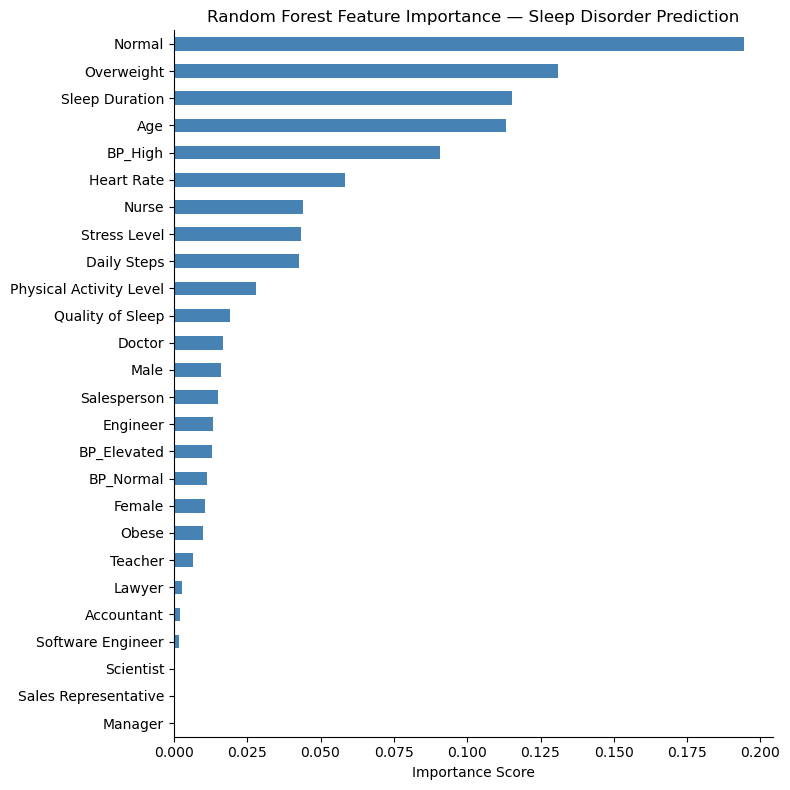

In [18]:
X = sleep_df[features]
y = sleep_df['Disorder Present']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"Random Forest Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Feature importance plot
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
imp.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Random Forest Feature Importance — Sleep Disorder Prediction')
ax.set_xlabel('Importance Score')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; 
padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Random Forest Feature Importance:</b></span> 

    
Each bar shows how much that variable reduced prediction uncertainty across all 
100 decision trees (longer bars indicate more important variables).  This is a different method from the permutation importance used earlier. Permutation importance measures the drop in performance on held-out data when a feature is scrambled, while Random Forest built-in importance measures impurity reduction during training. 


</bv>
Unlike the LASSO permutation importance which identified Normal BMI as the single dominant 
predictor, the Random Forest spreads importance more broadly across variables. 
This is because individual decision trees can capture non-linear interactions 
between features. For example, the combination of high blood pressure AND older 
age may be more predictive together than either variable alone. The Random Forest 
therefore gives a richer picture of how multiple health factors work together to 
predict sleep disorder risk, rather than identifying one single dominant predictor.



</div>

<h3 style="color: steelblue;">Confusion Matrix</h3>
<span style="color: steelblue; font-size: 14px;">
<b>The confusion matrix shows where the model makes correct and incorrect predictions. 
The diagonal represents correct predictions. Off-diagonal values are mistakes:
false positives (predicted disorder when healthy) and false negatives 
(predicted healthy when disorder is present).</b>
</span>

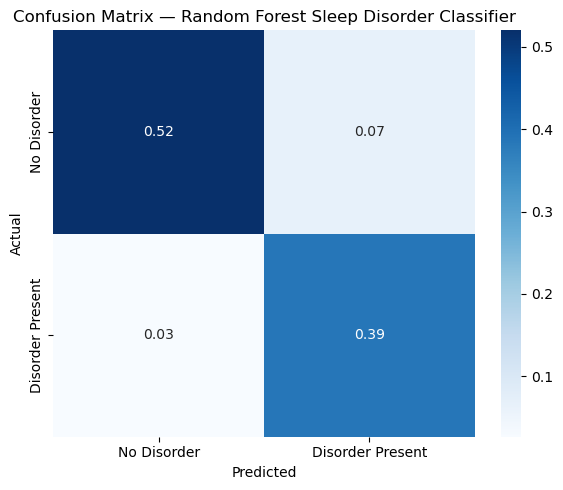

In [21]:
cm = confusion_matrix(y_test, y_pred, normalize='all')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['No Disorder', 'Disorder Present'],
            yticklabels=['No Disorder', 'Disorder Present'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Random Forest Sleep Disorder Classifier')
plt.tight_layout()
plt.show()

<h3 style="color: steelblue;">ROC Curve</h3>
<span style="color: steelblue; font-size: 14px;">
<b>The ROC curve shows the tradeoff between true positive rate and false positive rate 
at different classification thresholds. The AUC score summarizes overall performance:
1.0 is perfect, 0.5 is random. A higher AUC means the model better distinguishes 
between patients with and without sleep disorders.</b>
</span>

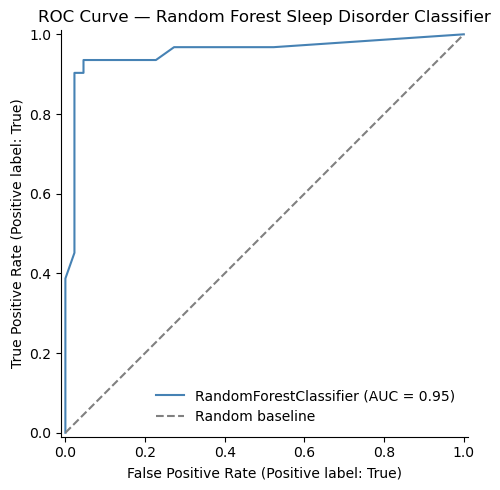

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, color='steelblue')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
ax.set_title('ROC Curve — Random Forest Sleep Disorder Classifier')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Finding:</b></span> On this split the Random Forest looks excellent: an AUC of 0.95 and 0.93 accuracy. The curve hugs the top-left corner, meaning that on this split the model identifies most disorder cases while keeping false positives low. But both numbers come from the same single split. The cross-validated accuracy (70.4%, in the model comparison below) is the more reliable estimate, and the gap between it and the single-split result reveals that this split was optimistic — across folds the Random Forest is actually unstable. The cross-validated result is the one to trust.
</div>

<h3 style="color: steelblue;">Model Comparison</h3>
<span style="color: steelblue; font-size: 14px;">
<b>We compare four classifiers using 5-fold cross-validation, which gives a more 
reliable accuracy estimate than a single train/test split by averaging performance 
across 5 different data folds.</b>
</span>

Logistic Regression       Accuracy: 0.882 (+/- 0.066)
Decision Tree             Accuracy: 0.762 (+/- 0.147)
Random Forest             Accuracy: 0.704 (+/- 0.168)
Gradient Boosting         Accuracy: 0.634 (+/- 0.193)


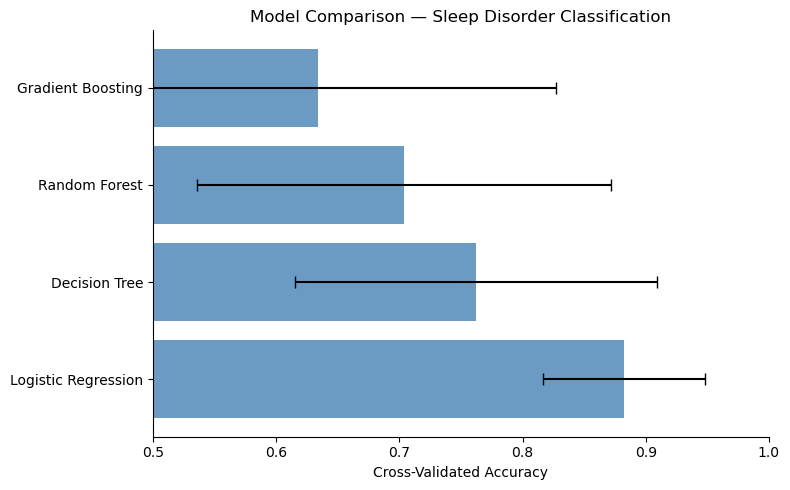

In [26]:
X = sleep_df[features]
y = sleep_df['Disorder Present']

models = {
    'Logistic Regression': make_pipeline(
        MinMaxScaler(), LogisticRegression(random_state=42, max_iter=1000)),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name:25} Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")

names = list(results.keys())
means = [results[n]['mean'] for n in names]
stds  = [results[n]['std']  for n in names]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(names, means, xerr=stds, color='steelblue', alpha=0.8, capsize=4)
ax.set_xlabel('Cross-Validated Accuracy')
ax.set_title('Model Comparison — Sleep Disorder Classification')
ax.set_xlim(0.5, 1.0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Interesting Result:</b></span> Logistic Regression achieved the highest cross-validated accuracy at 88.2%, outperforming Decision Tree (76.2%), Random Forest (70.4%), and Gradient Boosting (63.4%). Earlier we found that the Random Forest scored 0.93 on a single train/test split; the difference is that 5-fold cross-validation averages over five different splits and is far less sensitive to one lucky partition. The large error bars on Random Forest and Gradient Boosting indicate high variance across folds which is expected with a small dataset of 374 observations. With limited data, simpler models like Logistic Regression often outperform complex ensemble methods, which are more prone to overfitting and need more data to generalize well. </b>
<br><br>
Random Forest and Gradient Boosting are very powerful, but they need more data to generalize well. In this case, they were more prone to overfitting on training.
</div>

<h2 style="color: steelblue;">4. Question 2: What factors predict sleep quality?</h2>
<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Approach:</b></span> We use linear regression for 
continuous predictors and logistic regression (binarizing sleep quality at threshold = 7) 
for classification. Variables examined: stress level, sleep duration, heart rate, and 
physical activity.
</div>

Stress Level — MSE: 0.260
Stress Level — R²:  0.828


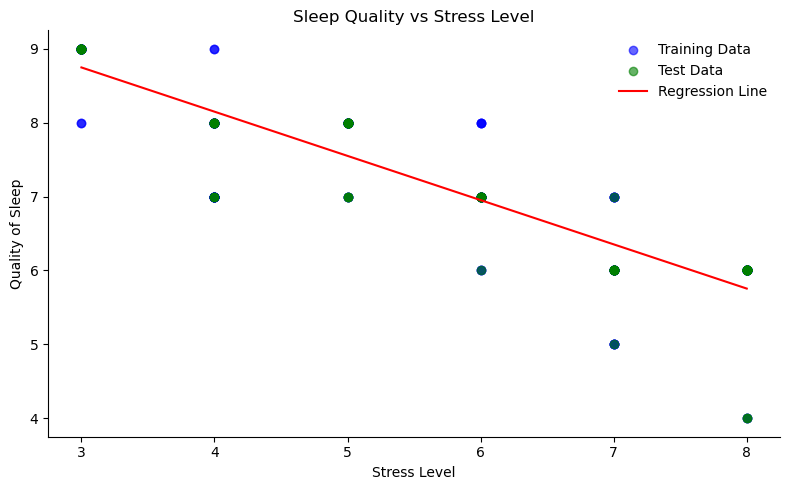

In [29]:
# Stress Level vs Sleep Quality
X = sleep_df[['Stress Level']]
y = sleep_df['Quality of Sleep']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model_stress = LinearRegression()
model_stress.fit(X_train, y_train)
y_pred = model_stress.predict(X_test)

print(f"Stress Level — MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"Stress Level — R²:  {r2_score(y_test, y_pred):.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)
plt.scatter(X_test,  y_test,  color='green', label='Test Data', alpha=0.6)
plt.plot(X_test.sort_values('Stress Level'),
         model_stress.predict(X_test.sort_values('Stress Level')),
         color='red', label='Regression Line')
plt.title('Sleep Quality vs Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Quality of Sleep')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Finding:</b></span> Stress level is the strongest 
single predictor of sleep quality in this dataset (R² = 0.828, MSE = 0.260). Higher 
stress is clearly associated with lower sleep quality — the regression line captures 
this strong negative trend. However it is worth noting that both variables are 
self-reported on subjective scales by the same individuals, which may inflate the 
correlation. Despite this caveat, the result is consistent with the broader literature 
linking chronic stress to poor sleep outcomes.
</div>

Sleep Duration — MSE: 0.355
Sleep Duration — R²:  0.765


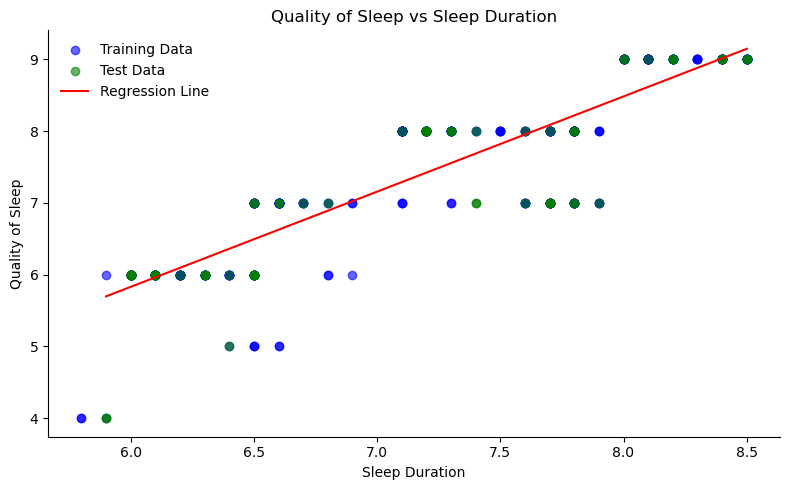

In [31]:
# Sleep Duration vs Sleep Quality 
X = sleep_df[['Sleep Duration']]
y = sleep_df['Quality of Sleep']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model_dur = LinearRegression()
model_dur.fit(X_train, y_train)
y_pred = model_dur.predict(X_test)

print(f"Sleep Duration — MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"Sleep Duration — R²:  {r2_score(y_test, y_pred):.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)
plt.scatter(X_test,  y_test,  color='green', label='Test Data', alpha=0.6)
plt.plot(X_test.sort_values('Sleep Duration'),
         model_dur.predict(X_test.sort_values('Sleep Duration')),
         color='red', label='Regression Line')
plt.title('Quality of Sleep vs Sleep Duration')
plt.xlabel('Sleep Duration')
plt.ylabel('Quality of Sleep')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Finding:</b></span> Sleep duration is a strong 
predictor of sleep quality (R² = 0.765, MSE = 0.355). Longer sleep duration is 
clearly associated with higher quality sleep — the regression line captures this 
positive trend well. The horizontal banding in the data reflects the discrete integer 
scale of the sleep quality variable (rated 1-10). This is the strongest single 
predictor in our Question 2 analysis alongside stress level.
</div>

Heart Rate — Test Accuracy: 0.840


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


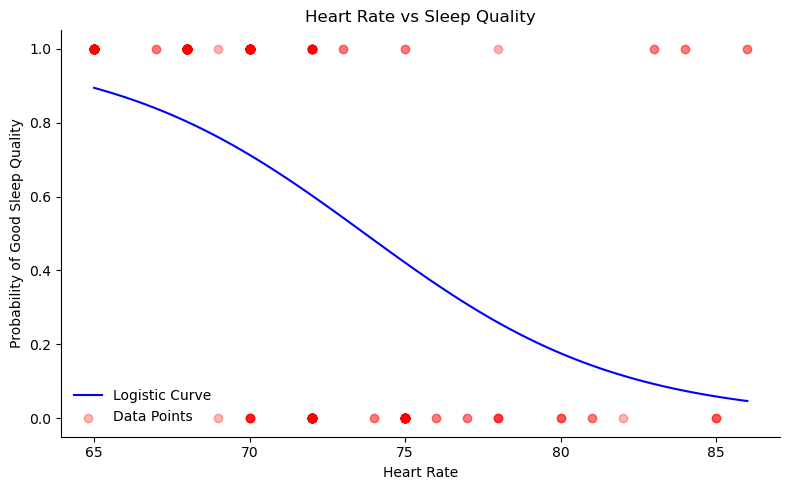

In [33]:
# Heart Rate vs Sleep Quality (Logistic) 
threshold = 7
y_binary = (sleep_df['Quality of Sleep'] >= threshold).astype(int)

X = sleep_df[['Heart Rate']]
y = y_binary

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model_hr = make_pipeline(MinMaxScaler(),
                         LogisticRegression(random_state=42, max_iter=1000))
model_hr.fit(X_train, y_train)
y_pred = model_hr.predict(X_test)
print(f"Heart Rate — Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")

x_range = np.linspace(X['Heart Rate'].min(), X['Heart Rate'].max(), 100).reshape(-1, 1)
y_proba = model_hr.predict_proba(x_range)[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(x_range, y_proba, color='blue', label='Logistic Curve')
plt.scatter(X, y, color='red', alpha=0.3, label='Data Points')
plt.xlabel('Heart Rate')
plt.ylabel('Probability of Good Sleep Quality')
plt.title('Heart Rate vs Sleep Quality')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Finding:</b></span> Heart rate is a strong predictor 
of sleep quality (accuracy = 0.840). As heart rate increases, the probability of good 
sleep quality drops sharply. This is consistent with research linking elevated resting heart 
rate to poor sleep and stress. The clean S-curve confirms logistic regression is an 
appropriate model for this relationship.
</div>

Physical Activity — Test Accuracy: 0.693


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


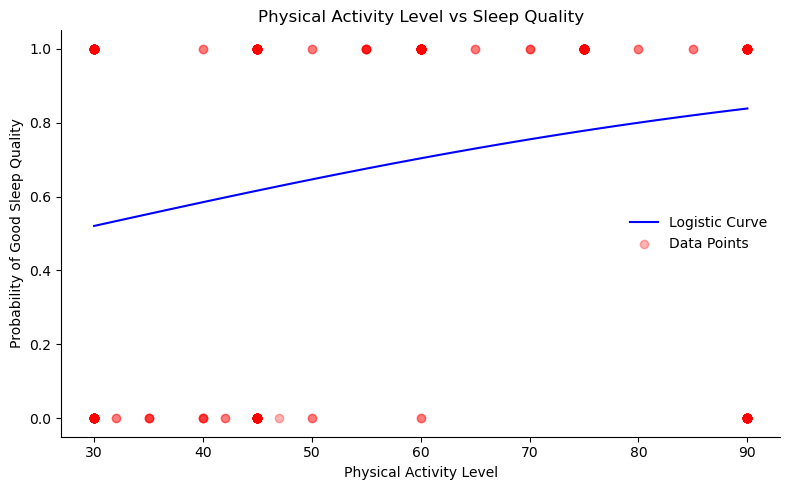

In [35]:
# Physical Activity vs Sleep Quality (Logistic) 
X = sleep_df[['Physical Activity Level']]
y = y_binary  # same binary target as the Heart Rate cell

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model_pa = make_pipeline(MinMaxScaler(),
                         LogisticRegression(random_state=42, max_iter=1000))
model_pa.fit(X_train, y_train)
y_pred = model_pa.predict(X_test)
print(f"Physical Activity — Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")

x_range = np.linspace(X['Physical Activity Level'].min(),
                      X['Physical Activity Level'].max(), 100).reshape(-1, 1)
y_proba = model_pa.predict_proba(x_range)[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(x_range, y_proba, color='blue', label='Logistic Curve')
plt.scatter(X, y, color='red', alpha=0.3, label='Data Points')
plt.xlabel('Physical Activity Level')
plt.ylabel('Probability of Good Sleep Quality')
plt.title('Physical Activity Level vs Sleep Quality')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 10px; border-radius: 4px;">
<span style="color: steelblue;"><b>Analysis on Physical Activity Level on Sleep Quality:</b></span> The flat logistic curve (accuracy = 0.693) suggests 
physical activity alone is a weak predictor of good sleep quality. A significant 
increase in physical activity is required to meaningfully change the probability — 
consistent with our feature selection results showing it as a lower-importance variable.
</div>

<h2 style="color: steelblue;">5. Summary of Findings</h2>
<div style="background-color: #f0f8ff; border-left: 4px solid steelblue; padding: 12px; border-radius: 4px;">
<span style="color: steelblue;"><b>Question 1 — Sleep Disorder Predictors:</b></span><br>
Permutation importance on the multivariate LASSO model ranked the Normal BMI category as the dominant feature. When examined individually with single-variable logistic regressions, systolic (0.91) and diastolic (0.89) blood pressure are by far the strongest single predictors, followed by age (0.69), heart rate (0.68), and self-reported sleep quality (0.64). 
    
</br>
</br>
On model choice: the Random Forest scored highest on a single train/test split (0.93), but under 5-fold cross-validation Logistic Regression was both the most accurate and the most stable (0.88), while the Random Forest was the least stable. On a small, near-linearly-separable dataset, the simpler model generalizes better. An important charactertistic to remember is that blood pressure is very tightly coupled to the disorder label in this dataset, so its high single-variable accuracy partly reflects that structure rather than the model alone.<br><br>
<span style="color: steelblue;"><b>Question 2 — Sleep Quality Predictors:</b></span><br>
Lower stress level (R² = 0.83), longer sleep duration (R² = 0.77), lower heart rate, and higher physical activity are all associated with better sleep quality. Stress level alone is the single strongest predictor of sleep quality in this dataset.
</div>